### Import packages!

In [1]:
!hostname

ne1dg6-008.nygenome.org


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from datetime import datetime
import scanpy as sc
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score
from matplotlib.font_manager import FontProperties
import anndata as ad
from scipy.stats import ranksums
import matplotlib.cm as cm
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import umap
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
import statsmodels.api as sm
from statsmodels.stats.multitest import fdrcorrection
import sys
import gffutils
import os

# Add the directory containing IsovizPy.py to the Python path for visualization of ATSEs and isoforms 
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/visualization')
import IsovizPy as ja

# Import functions from utilities.py 
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis')
from LeafletFA_utilities import *
import importlib

# Increase the font scale for seaborn
sns.set(font_scale=1.5)  # Adjust this value to increase or decrease font size
sns.set_style("white")  # Set the background to white

In [3]:
# Load data and create the database (note this may take 1-2 minutes)
gtf_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/gencode.vM19/genes/genes.gtf"
# db = ja.create_db(gtf_file, "gencode.vM19") do this only once! 

# Path to the database file created previously
db_path = "gencode.vM19"

# Load the database
db = gffutils.FeatureDB(db_path, keep_order=True)

### Load all datasets!

In [ ]:
# Specify whether GTF file was used during ATSE mapping (whether splice junctions are annotated to genes...)
gtf_used = False

# Today's date 
today = datetime.today().strftime('%Y%m%d')
# Make new directory within current working directory to store all the figures and resutls that will be generated in this notebook
results_dir = f"results_{today}"
os.makedirs(results_dir, exist_ok=True)
os.chdir(results_dir)

# Specify path that contains results from model training 
model_training_results_path = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/slurm/11132024/analysis_20241113_183550_K_30_UsingWaypoints_Prior_NoGlobalPrior_NumEpochs_100_LearnedConc_Inits_1_CellType_cell_type_grouped_Random_27018"
K = 30 # Number of learned factors 
ATSE_file="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/NOGTF/tabula_senis_annotationFREE_intron_clusters_50_500000_100_20241102_single_cell.gz"

In [ ]:
# Splicing anndata object 
# splice_adata = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/ATSE_Anndata_Object_with_initializations_20241017_162621.h5ad" (version used for Recomb)
splice_adata = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/NOGTF/ATSE_Anndata_noGTF_Object_NO_GTF_with_initializations_20241118_212258.h5ad"
splice_adata = sc.read_h5ad(splice_adata)

# Load the expression data (.h5ad file)
exp_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/TMS_Anndata_GeneExpression_2024-11-12.h5ad"
adata = sc.read_h5ad(exp_file)
adata.var["mouse_gene_name"] = adata.var.index

# Mapped ATSE coordinates 
atses = pd.read_csv(ATSE_file, sep="}")

In [4]:
atses = pd.read_csv("/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/tabula_senis_annotationFREE_intron_clusters_50_500000_100_20250123_single_cell.gz", sep="}")

In [5]:
# add start end column to atses using junction_id column X_X_X_X second and third X
atses["start"] = atses["junction_id"].apply(lambda x: x.split("_")[1])
atses["end"] = atses["junction_id"].apply(lambda x: x.split("_")[2])

In [6]:
# remove "Count" column and update it with how much junctions are in each cluster
atses = atses.drop(columns=["Count"])
junc_counts = atses.groupby("Cluster").size().reset_index(name="Count")
atses = atses.merge(junc_counts, on="Cluster")

In [13]:
# Load data and create the database (note this may take 1-2 minutes - do this once!)
gtf_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/gencode.vM19/genes/genes.gtf"  
# Path to the database file created previously
db_path = "/gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis/LeafletFA_analysis/gencode.vM19"
# Load the database
db = gffutils.FeatureDB(db_path, keep_order=True)

In [22]:
# sample random clusters in atses["Cluster"] and look at their junctions 
clust_sample = atses.Cluster.sample(1).values
test_clust = atses[atses.Cluster.isin(clust_sample)]

fasta_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/gencode.vM19/fasta/genome.fa"
# Add usage_ratio to test_clust
test_clust["usage_ratio"] = 0

# Convert junction_ids to format that can easily be overlapped with transcript coordinates stored in our database 
splice_junctions = ja.convert_junction_ids(test_clust[["junction_id", "Cluster", "usage_ratio"]])
pd.DataFrame(ja.check_splice_site_motifs(fasta_file, splice_junctions)).splice_motif.value_counts()

/scratch/ipykernel_1488353/642920312.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_clust["usage_ratio"] = 0


splice_motif
GT-AG            300
GC-AG             45
non-canonical      8
Name: count, dtype: int64

In [36]:
test_clust_ss = pd.DataFrame(ja.check_splice_site_motifs(fasta_file, splice_junctions)).sort_values("splice_motif")

test_clust_ss["junction_id"] = (
    test_clust_ss["chrom"].astype(str) + "_" +
    test_clust_ss["start"].astype(str) + "_" +
    test_clust_ss["end"].astype(str) + "_" +
    test_clust_ss["strand"].astype(str)
)

# remove start and end columns from test_clust_ss
test_clust_ss = test_clust_ss.drop(columns=["start", "end", "usage_ratio"])
test_clust_ss = test_clust_ss.merge(test_clust, on=["junction_id"])

,chrom,name,strand,splice_motif,donor_seq,acceptor_seq,junction_id,num_cells_with_junc,total_read_counts,total_5ss_counts,total_3ss_counts,5SS_usage,3SS_usage,Cluster,start,end,Count,usage_ratio
0,chr19,junction_82162,-,GC-AG,GC,AG,chr19_5492693_5493690_-,22,275,275,1945,1.000000,0.141388,57228,5492693,5493690,353,0
1,chr19,junction_122173,-,GC-AG,GC,AG,chr19_5844112_5845245_-,10,152,152,538,1.000000,0.282528,57228,5844112,5845245,353,0
2,chr19,junction_113620,-,GC-AG,GC,AG,chr19_5802071_5802154_-,15,357,2358,3361,0.151399,0.106218,57228,5802071,5802154,353,0
3,chr19,junction_122088,-,GC-AG,GC,AG,chr19_5629112_5801094_-,36,238,970,238,0.245361,1.000000,57228,5629112,5801094,353,0
4,chr19,junction_121648,-,GC-AG,GC,AG,chr19_5802351_5802458_-,42,2938,2938,4692,1.000000,0.626172,57228,5802351,5802458,353,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
348,chr19,junction_87734,-,non-canonical,AC,CC,chr19_5897443_5902664_-,48,1206,1206,1772,1.000000,0.680587,57228,5897443,5902664,353,0
349,chr19,junction_129462,-,non-canonical,AT,CC,chr19_5897444_5897862_-,10,155,533,155,0.290807,1.000000,57228,5897444,5897862,353,0
350,chr19,junction_116195,-,non-canonical,AC,CC,chr19_5897442_5902664_-,11,188,188,1772,1.000000,0.106095,57228,5897442,5902664,353,0
351,chr19,junction_131164,-,non-canonical,AC,CC,chr19_5293164_5293251_-,11,396,1062,396,0.372881,1.000000,57228,5293164,5293251,353,0


In [46]:
test_clust_ss.splice_motif.value_counts()

splice_motif
GT-AG            300
GC-AG             45
non-canonical      8
Name: count, dtype: int64

In [47]:
# filter just the junctions that don't have canonical splice sites
test_clust_ss[test_clust_ss.splice_motif == "GC-AG"]["junction_id"]
splice_junctions = ja.convert_junction_ids(test_clust_ss[test_clust_ss.splice_motif == "GC-AG"][["junction_id", "Cluster", "usage_ratio"]])
splice_junctions

[{'chrom': 'chr19',
  'start': 5492693,
  'end': 5493690,
  'name': 'junction_1',
  'strand': '-',
  'usage_ratio': 0},
 {'chrom': 'chr19',
  'start': 5844112,
  'end': 5845245,
  'name': 'junction_2',
  'strand': '-',
  'usage_ratio': 0},
 {'chrom': 'chr19',
  'start': 5802071,
  'end': 5802154,
  'name': 'junction_3',
  'strand': '-',
  'usage_ratio': 0},
 {'chrom': 'chr19',
  'start': 5629112,
  'end': 5801094,
  'name': 'junction_4',
  'strand': '-',
  'usage_ratio': 0},
 {'chrom': 'chr19',
  'start': 5802351,
  'end': 5802458,
  'name': 'junction_5',
  'strand': '-',
  'usage_ratio': 0},
 {'chrom': 'chr19',
  'start': 5049459,
  'end': 5049698,
  'name': 'junction_6',
  'strand': '-',
  'usage_ratio': 0},
 {'chrom': 'chr19',
  'start': 5801961,
  'end': 5802154,
  'name': 'junction_7',
  'strand': '-',
  'usage_ratio': 0},
 {'chrom': 'chr19',
  'start': 5455661,
  'end': 5455734,
  'name': 'junction_8',
  'strand': '-',
  'usage_ratio': 0},
 {'chrom': 'chr19',
  'start': 5802061,


In [48]:
# Check junction annotations
junction_annotation_results = ja.check_junction_annotation(splice_junctions, db)

# Extract unique transcript IDs from junction_labels
unique_transcripts = list({transcript for label in junction_annotation_results for transcript in label['transcripts']})

# Fetch transcript exon coordinates and determine plot boundaries
transcript_data = ja.fetch_transcripts_and_annotations(db, unique_transcripts)

# Get start and end coordinates for our plot 
region_start, region_end = ja.determine_region_boundaries(splice_junctions)

# Optionally - confirm whether your splice junctions fully annotate to known exons on 5' or 3' side! 
ja.check_junction_annotation(splice_junctions, db)

100%|██████████| 45/45 [00:00<00:00, 224.23it/s]


[{'junction': 'chr19:5492693-5493690',
  'strand': '-',
  'label_5_prime': "unannotated on 5'",
  'label_3_prime': "unannotated on 3'",
  'position_off_5_prime': None,
  'position_off_3_prime': None,
  'transcripts': []},
 {'junction': 'chr19:5844112-5845245',
  'strand': '-',
  'label_5_prime': "unannotated on 5'",
  'label_3_prime': "unannotated on 3'",
  'position_off_5_prime': None,
  'position_off_3_prime': None,
  'transcripts': []},
 {'junction': 'chr19:5802071-5802154',
  'strand': '-',
  'label_5_prime': "unannotated on 5'",
  'label_3_prime': "unannotated on 3'",
  'position_off_5_prime': None,
  'position_off_3_prime': None,
  'transcripts': []},
 {'junction': 'chr19:5629112-5801094',
  'strand': '-',
  'label_5_prime': "unannotated on 5'",
  'label_3_prime': "unannotated on 3'",
  'position_off_5_prime': None,
  'position_off_3_prime': None,
  'transcripts': []},
 {'junction': 'chr19:5802351-5802458',
  'strand': '-',
  'label_5_prime': "unannotated on 5'",
  'label_3_prime

Plot saved to Sssca1_no_usage_no_lines_20250124.pdf!


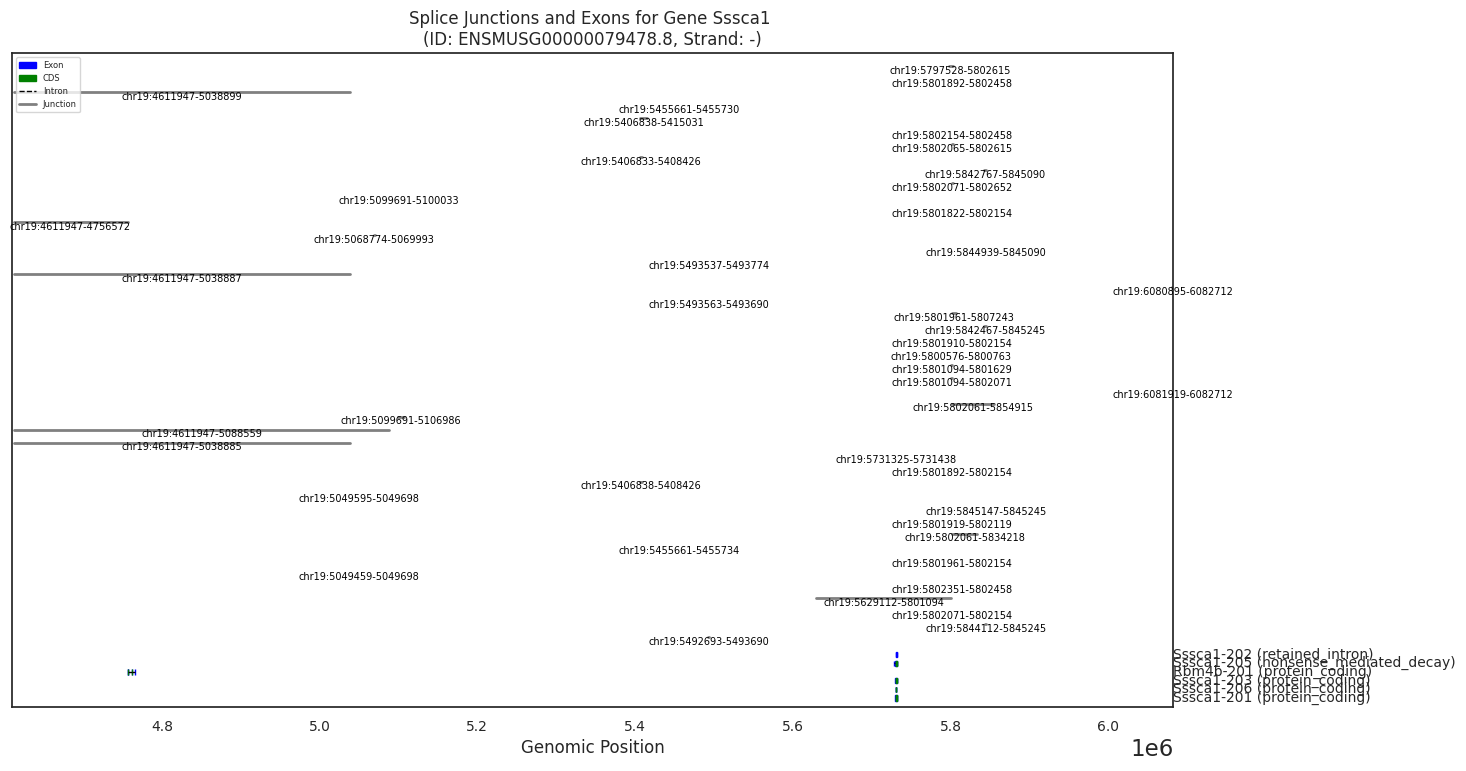

In [50]:
ja.plot_exons_and_junctions(db, transcript_data, splice_junctions, region_start-1000, region_end-1000, base_width=15, trans_height=0.8, show_usage=False, show_junc_lines=False)

In [ ]:
# Load the latent variables (pickle file)
latent_vars_file = f"{model_training_results_path}/latent_vars.pkl"
latent_vars = pd.read_pickle(latent_vars_file)

# Specify prined latent variables file using 
pruned_latent_vars_file = f"{model_training_results_path}/pruned_latent_vars.pkl"
pruned_vars = pd.read_pickle(pruned_latent_vars_file)

# Load the all_vs_all results (CSV file)
albf_scores_file = f"{model_training_results_path}/all_vs_all_results.csv"
albf_scores = pd.read_csv(albf_scores_file)
albf_scores["junction_id_index"] = albf_scores["Junction_Index"]

# If GTF file was used, specify columns that include "gene_id" otherwise no "gene_id"
if gtf_used:
    juncs_factors_albf = splice_adata.var[["junction_id", "gene_id", "Cluster", "junction_id_index"]].merge(albf_scores,on="junction_id_index")
else:
    juncs_factors_albf = splice_adata.var[["junction_id", "Cluster", "junction_id_index"]].merge(albf_scores,on="junction_id_index")

### Assemble all aging related genes

In [ ]:
# Aging genes from eLife paper
age_elife = "/gpfs/commons/groups/knowles_lab/Karin/elife-62293-supp3-v2.xlsx"
age_elife = pd.read_excel(age_elife, header=0, index_col=None)

# Genes for which the fraction of cells expressing significantly increases with age
supptab4 = "/gpfs/commons/groups/knowles_lab/Karin/41586_2020_2496_MOESM6_ESM.xlsx"
supptab4 = pd.read_excel(supptab4, header=0, index_col=None, sheet_name="all_genes")

# Microglia AD signature vs healthy, not sure how to interpret the 500 genes here...  
supptab10 = "/gpfs/commons/groups/knowles_lab/Karin/41586_2020_2496_MOESM12_ESM.xlsx"
supptab10 = pd.read_excel(supptab10, header=1, index_col=None, sheet_name="Amit_expression_mic3tomic1")

# Global aging genes from TMS paper
global_aging_genes = "/gpfs/commons/groups/knowles_lab/Karin/27857814" # from https://figshare.com/articles/dataset/tms_gene_data_rv1/12827615?file=27857814
global_aging_genes = pd.read_csv(global_aging_genes, sep='\t')

# TMS genes 
tms_paper = global_aging_genes["global_aging_genes"].unique()
age_elife_global = age_elife[age_elife["global_aging"]].gene.unique()

# Combine both lists into one, then use set() to remove duplicates
combined_genes = list(set(tms_paper.tolist() + age_elife_global.tolist()))

# Print the number of unique genes
print(f"Total unique genes: {len(combined_genes)}")

### Load list of RBPs and senescence markers!

In [ ]:
# RBP file
excel_file = "/gpfs/commons/groups/knowles_lab/Karin/VanNostrand_2020_supptable1_41586_2020_2077_MOESM3_ESM.xlsx"

# Load the Excel file
rbps = pd.read_excel(excel_file, header=1, index_col=None)
# Rename the first two columns to be gene_name and gene_id 
rbps.rename(columns={rbps.columns[0]: 'gene_name', rbps.columns[1]: 'gene_id'}, inplace=True)

# Convert the gene_name column to capitalize only the first letter and lowercase the rest
rbps['mouse_gene_name'] = rbps['gene_name'].str.capitalize()
print(rbps[['gene_name', 'mouse_gene_name', 'gene_id']].head())

### Load latent splicing factors!

In [ ]:
assign_post = pruned_vars["pruned_assign_post"]
psi_learned = pruned_vars["pruned_psi_learned"]
pi = pruned_vars["pruned_pi"]

# let's get a new junc_ratio by multiplying psi_assigned and learned PSI! then use that to plot junnction usagea cross cells from different age groups.
new_junc_ratio = assign_post @ psi_learned
splice_adata.layers["new_junc_ratio"] = new_junc_ratio
splice_adata.obs.age.value_counts()

psi_learned = psi_learned
psi_learned_df = pd.DataFrame(psi_learned.T, columns=[f'factor_{i}' for i in range(1, K + 1)])
psi_learned_df["junction_id_index"] = psi_learned_df.index
psi_learned_df = psi_learned_df.merge(splice_adata.var, on="junction_id_index")
splice_adata.var = psi_learned_df

### Figure out which latent spaces are associated with aging

In [ ]:
# Step 1: Convert assign_post to a DataFrame and name the columns as 'factor_0', 'factor_1', ..., 'factor_49'
factor_names = [f'factor_{i}' for i in range(1, K + 1)]
assign_post_df = pd.DataFrame(assign_post, columns=factor_names)
assign_post_df.index = splice_adata.obs.index
# Step 2: Attach the factor names DataFrame (assign_post_df) to adata.obs
splice_adata.obs = pd.concat([splice_adata.obs, assign_post_df], axis=1)

### Run logistic regression to predict age as a categorical variable! 

In [ ]:
print(K)

In [ ]:
splice_adata.var

In [ ]:
# Assuming splice_adata is your AnnData object and the latent factors are stored in `splice_adata.obs`
feature = "age"
accuracy, coefficients_age = logistic_regression_feature_prediction_simple(splice_adata, feature, K)

# Check the accuracy and coefficients
print(f"Accuracy for {feature}: {accuracy}")

# For each cell type, we will take the top 10 factors by absolute coefficient value.
top_factors_by_age = coefficients_age.apply(lambda x: x.abs().nlargest(10).index.tolist(), axis=1)

# Define the desired order of indices
new_index_order = ['3m', '18m', '24m']

# Reindex the DataFrame with the new order
coefficients_age = coefficients_age.reindex(new_index_order)

In [ ]:
plot_clustermap(coefficients_age, highlighted_factors=['factor_17', 'factor_18', 'factor_19'])

In [ ]:
# Step 1: Assign numeric values to the age groups (in the order of the rows in the DataFrame)
age_mapping = {'3m': 3, '18m': 18, '24m': 24}
numeric_ages = coefficients_age.index.map(age_mapping)
correlations = coefficients_age.apply(lambda x: np.corrcoef(numeric_ages, x)[0, 1])
sorted_correlations = correlations.sort_values()
# Display the top 5 negatively and top 5 positively correlated factors
print("Top 5 Negatively Correlated Factors with Age:")
print(sorted_correlations.head(5))

print("\nTop 5 Positively Correlated Factors with Age:")
print(sorted_correlations.tail(5))

In [ ]:
plot_top_factor_distributions(splice_adata, top_factors=["factor_21", "factor_18", "factor_8"], age_column="age", plot_type="boxenplot")

In [ ]:
create_age_category(splice_adata)

factors = [f'factor_{i}' for i in range(1, K+1)]

# Call the function to get results
result_table = compare_factors_by_age(splice_adata, factors, cell_type_col='cell_type_grouped')

# Display the result table
print(result_table)

In [ ]:
# Step 1: Create a pivot table for delta_median and avg_factor_activity
delta_median_pivot = result_table.pivot(index='cell_type', columns='factor', values='delta_median')
avg_activity_pivot = result_table.pivot(index='cell_type', columns='factor', values='avg_factor_activity')
median_activity_pivot = result_table.pivot(index='cell_type', columns='factor', values='median_factor_activity')

# Step 2: Masking cells with median activity <= 0.001 for delta_median
# mask = avg_activity_pivot < 0.01

# Step 3: Define a colormap that includes black for masked cells
cmap = sns.color_palette("seismic", as_cmap=True)
cmap.set_bad(color='grey')  # Set masked values to black

# Step 3: Cluster the delta_median_pivot to get row and column order
g = sns.clustermap(delta_median_pivot, cmap="seismic", cbar=True, 
                   annot=False, center=0, vmin=-0.05, vmax=0.05, figsize=(4, 4),
                   row_cluster=True, col_cluster=True)

In [ ]:
# Extract the cluster order from the clustermap
cell_type_order = g.dendrogram_row.reordered_ind
factor_order = g.dendrogram_col.reordered_ind

# Reindex avg_activity_pivot to match the clustered order of delta_median_pivot
avg_activity_pivot = avg_activity_pivot.iloc[cell_type_order, factor_order]
delta_median_pivot = delta_median_pivot.iloc[cell_type_order, factor_order]  # Reorder this as well

# Step 4: Create a figure for two side-by-side heatmaps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Step 5: Plot the delta_median_pivot heatmap with the clustering-based order
sns.heatmap(delta_median_pivot, cmap="seismic", ax=ax1, cbar=True, 
            annot=False, center=0, vmin=-0.05, vmax=0.05, xticklabels=True, yticklabels=True)

# Step 6: Plot the avg_activity_pivot heatmap with the same order as delta_median_pivot
sns.heatmap(avg_activity_pivot, cmap="coolwarm", ax=ax2, cbar=True, 
            annot=False, center=0, vmin=avg_activity_pivot.min().min(), vmax=avg_activity_pivot.max().max(), 
            xticklabels=True, yticklabels=False)  # Show x-axis ticks but hide y-axis ticks

# Step 7: Set titles for the plots
ax1.set_title('Delta Median Factor Activity (Old - Young)', fontsize=10)
ax2.set_title('Average Factor Activity in Cell Type', fontsize=10)

# Step 8: Set x-axis and y-axis labels for the left plot (since it's clustered) 
ax1.set_xticklabels(delta_median_pivot.columns, rotation=90, fontsize=10)
ax1.set_yticklabels(delta_median_pivot.index, rotation=0, fontsize=10)
ax1.set_ylabel("Cell Type")
ax1.set_xlabel("Factor")

# Set x-axis labels for the right plot (factors should be shown)
ax2.set_xticklabels(avg_activity_pivot.columns, rotation=90, fontsize=10)
ax2.set_ylabel("Cell Type")
ax2.set_xlabel("Factor")

# Adjust layout
plt.tight_layout()

# Step 5: Save the figure as a PDF with filename including current date
current_date = datetime.now().strftime("%Y-%m-%d")
filename = f"supp_heatmaps_delta_avg_factors_{current_date}.pdf"
plt.savefig(filename, format='pdf')

plt.show()

### Plot factor distribution by age either in one cell type or across all!

In [ ]:
plot_factor_distribution_by_age(splice_adata, "factor_26", "HEPATOCYTE")

In [ ]:
plot_factor_distribution_by_age(splice_adata, "factor_2", None)

In [ ]:
plot_factor_distribution_by_age(splice_adata, "factor_8", None)

### Plot factor distribution across all cells in cell type regardless of age 

In [ ]:
plot_factor_distribution(splice_adata, "MICROGLIA", "factor_14")

In [ ]:
# Step 1: Convert age categories to numerical values (3m -> 3, 18m -> 18, 24m -> 24)
age_map = {'3m': 1, '18m': 2, '24m': 3}
splice_adata.obs['age_numeric'] = splice_adata.obs['age'].map(age_map).astype(int)
# Example usage
rmse, coefficients_df = linear_regression_age_prediction(splice_adata, K=30)

In [ ]:
splice_adata.obs['age_numeric'].values

In [ ]:
# Sort the DataFrame by coefficient in descending order
coefficients_df = coefficients_df.sort_values(by='Coefficient', ascending=False)

In [ ]:
# Select columns that contain "factor" in their name and ensure they are numeric
factor_columns = splice_adata.obs.filter(like='factor')

# Convert the selected factor columns to numeric, if they are not already
for col in factor_columns.columns:
    splice_adata.obs[col] = pd.to_numeric(splice_adata.obs[col], errors='coerce')

# Group by age and calculate the median for these factor columns
age_groups = splice_adata.obs.groupby('age_category')[factor_columns.columns].median()

# Compute the delta between 3m, 18m, and 24m for each factor
deltas = pd.DataFrame({
    'Factor': [f'factor_{i}' for i in range(1, K + 1)],
    'Delta_OY': age_groups.loc['old'] - age_groups.loc['young']
})

coefficients_with_deltas = deltas.merge(coefficients_df)

In [ ]:
# Set global font size for the entire plot
plt.rcParams.update({'font.size': 12})

# Sort the DataFrame by coefficient in descending order
coefficients_with_deltas = coefficients_with_deltas.sort_values(by='Coefficient', ascending=False)

# Factors to highlight in red
highlight_factors = ['factor_17', 'factor_2']

# Create figure with two subplots (side by side)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 6), gridspec_kw={'width_ratios': [2, 1]}, sharey=True)

# Plot 1: Coefficients with error bars using plt.errorbar
ax1.errorbar(coefficients_with_deltas['Coefficient'], coefficients_with_deltas['Factor'],
             xerr=1.96 * coefficients_with_deltas['Standard Error'], fmt='o', capsize=3, markersize=4, color='lightblue')

# Add a vertical line at x = 0 for reference
ax1.axvline(0, color='gray', linestyle='--')

# Set axis labels and title
ax1.set_xlabel('Factor Aging Coefficient \n(Linear Regression)', fontsize=14)
ax1.set_ylabel('Factors', fontsize=13)

# Highlight specific factors in red
y_ticks = ax1.get_yticklabels()
for tick in y_ticks:
    if tick.get_text() in highlight_factors:
        tick.set_color('red')

# Plot 2: Delta (Old - Young) 
ax2.barh(y=coefficients_with_deltas['Factor'], width=coefficients_with_deltas['Delta_OY'], 
         color='lightcoral', label='Delta YO')
ax2.axvline(0, color='gray', linestyle='--')

# Set axis labels and title for delta plot
ax2.set_xlabel('Factor Cell Activity\nDelta (Old - Young)', fontsize=13)
ax2.set_xlim(-0.035, 0.1)

# Adjust font size of tick labels for both axes
ax1.tick_params(axis='both', which='major', labelsize=12)
ax2.tick_params(axis='both', which='major', labelsize=12)

# Adjust layout
plt.tight_layout()

# Save as pdf 
plt.savefig("/gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis/LeafletFA_analysis/linear_regression_factors_aging_with_delta.pdf", format='pdf')

# Show the plot
plt.show()

In [ ]:
coefficients_with_deltas

In [ ]:
splice_adata

In [ ]:
# Step 1: Adjust p-values using FDR correction (Benjamini-Hochberg)
# Add FDR-adjusted p-values to the cell_type_df
_, result_table['p_value_fdr'] = fdrcorrection(result_table['p_value'])

# Merge the two tables on the 'Factor' column
merged_df = pd.merge(result_table, coefficients_df, how='inner', left_on='factor', right_on='Factor')
threshold = 2 

# Step 1: Filter for significant factors (e.g., p-value < 0.05)
# Step 3: Filter for significant factors based on FDR-adjusted p-values and absolute delta_median > 0.05
significant_factors = merged_df[
    (merged_df['p_value_fdr'] < 0.05) & 
    (merged_df['delta_median'].abs() > 0.05)
]

# Step 2: Group by factor and summarize the number of cell types where the factor is significantly different
factor_summary = significant_factors.groupby('factor').agg(
    num_significant_cell_types=('cell_type', 'count'),  # Count how many cell types show significant changes
    avg_delta_median=('delta_median', 'mean'),          # Average delta_median across all cell types
    min_delta_median=('delta_median', 'min'),           # Minimum delta_median (enriched in young)
    max_delta_median=('delta_median', 'max'),           # Maximum delta_median (enriched in old)
    avg_coefficient=('Coefficient', 'mean')             # Average age coefficient from linear regression
).reset_index()

# Step 3: Identify factors that are commonly enriched (shared across many cell types)
shared_factors = factor_summary[factor_summary['num_significant_cell_types'] > threshold]  # Set a threshold, e.g., > 5 cell types

# Step 4: Identify factors that are strongly enriched in a subset (i.e., large delta in some cell types)
subset_enriched_factors = factor_summary[factor_summary['num_significant_cell_types'] <= threshold]

# Step 5: Sort the results for better readability
shared_factors = shared_factors.sort_values(by='num_significant_cell_types', ascending=False)
subset_enriched_factors = subset_enriched_factors.sort_values(by='avg_delta_median', ascending=False)

# Display the summary
print("Factors Shared Across Many Cell Types:")
print(shared_factors)

print("\nFactors Strongly Enriched in a Subset of Cell Types:")
print(subset_enriched_factors)

In [ ]:
fact19_age = result_table[result_table["factor"] == "factor_19"].sort_values(by="delta_median")
fact15_age = result_table[result_table["factor"] == "factor_15"].sort_values(by="delta_median")
fact12_age = result_table[result_table["factor"] == "factor_12"].sort_values(by="delta_median")
fact2_age = result_table[result_table["factor"] == "factor_2"].sort_values(by="delta_median")
fact14_age = result_table[result_table["factor"] == "factor_14"].sort_values(by="delta_median")
fact26_age = result_table[result_table["factor"] == "factor_26"].sort_values(by="delta_median")

In [ ]:
plot_factor_medians(fact14_age, 'factor_14')

In [ ]:
plot_factor_medians(fact26_age, 'factor_26')

In [ ]:
plot_factor_medians(fact2_age, 'factor_2')

In [ ]:
# Assuming splice_adata is your AnnData object and the latent factors are stored in `splice_adata.obs`
feature = "cell_type_grouped"
# Call the function
accuracy, coefficients_cell_type = logistic_regression_feature_prediction_simple(splice_adata, feature, K)
# Check the accuracy and coefficients
print(f"Accuracy for {feature}: {accuracy}")
# For each cell type, we will take the top 10 factors by absolute coefficient value.
top_factors_by_cell_type = coefficients_cell_type.apply(lambda x: x.abs().nlargest(5).index.tolist(), axis=1)

In [ ]:
splice_adata.var_names = splice_adata.var["junction_id"]

### Get UMAP based on assign_post embeddings in splice_data.obs columns with "factor" in them 

In [ ]:
# Step 1: Extract the assign_post embeddings from splice_data.obs
# Get all columns with 'factor' in their names
factor_columns = [col for col in splice_adata.obs.columns if 'factor' in col]
embedding = splice_adata.obs[factor_columns].values

# Step 2: Perform UMAP on the factor embeddings
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
umap_embedding = reducer.fit_transform(embedding)
splice_adata.obsm['X_umap'] = umap_embedding

shuffled_indices = np.random.permutation(splice_adata.obs.index)
shuffled_adata = splice_adata[shuffled_indices, :]

In [ ]:
if gtf_used:
    genes_ids = atses[["gene_id", "gene_name"]].drop_duplicates()
    aging_genes = global_aging_genes[global_aging_genes["global_aging_genes"].isin(splice_adata.var["gene_name"])].global_aging_genes.values
    genes_ids['aging_genes'] = genes_ids['gene_name'].isin(combined_genes).map({True: 'yes', False: 'no'})
    genes_ids.aging_genes.value_counts()
    juncs_factors_albf = juncs_factors_albf.merge(genes_ids)

### Look at ALBF scores of junction within a specific factor

In [ ]:
# Step 1: Select factor of interest 
factor_int = "Factor 19" 

if gtf_used:

    subset_df = juncs_factors_albf[juncs_factors_albf["Factor"] == factor_int]
    
    # Step 2: Sort first by 'aging_genes' (placing 'yes' first) and then by 'ALBF' in descending order
    sorted_df = subset_df.sort_values(by=["aging_genes", "ALBF"], ascending=[False, False])
    sorted_df = subset_df.sort_values(by="ALBF", ascending=False)
    
    # Step 2: Select the top 50 junctions
    top_50_junctions = sorted_df.head(20)
    
    # Step 3: Create a bar plot to show the top 50 junctions and their ALBF scores
    plt.figure(figsize=(7, 9))
    
    # Define colors based on the aging_genes column ('yes' for aging genes, 'no' for non-aging genes)
    color_palette = {'yes': 'red', 'no': 'blue'}
    
    # Plot the barplot with different colors based on the aging_genes column
    sns.barplot(x="ALBF", y="junction_id", data=top_50_junctions, hue="aging_genes", dodge=False, palette=color_palette)
    
    # Italicize gene names
    italic_font = FontProperties(style='italic')
    
    # Add the gene names as labels for each junction with italic font
    for i in range(top_50_junctions.shape[0]):
        plt.text(top_50_junctions["ALBF"].values[i] + 1, i, 
                 top_50_junctions["gene_name"].values[i], 
                 fontproperties=italic_font, color='black', va="center", fontsize=12)
    
    # Set labels and title
    plt.xlabel("ALBF Score", fontsize=14)
    plt.ylabel("Junction ID", fontsize=14)
    plt.yticks(fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{factor_int}_top_junctions.pdf", format='pdf')
    
    # Show the plot
    plt.show()

### Rerun logistic regression to predict age groups comparing splicing vs gene expression based signals

In [ ]:
# Assume splice_adata and gene_expression_adata are already loaded and preprocessed
feature_to_predict = 'age'  # Replace target feature

accuracies, aurocs, auprs, models, label_encoder, coefficients_dfs = logistic_regression_feature_prediction(
    splice_adata,
    adata,
    feature=feature_to_predict,
    K=K,
    n_pcs=50,
    test_size=0.2,
    random_state=42
)

print(accuracies)

In [ ]:
coef_splicing = coefficients_dfs['splicing']
coef_gene_expression = coefficients_dfs['gene_expression']
coef_combined = coefficients_dfs['combined']
coef_tissue_only = coefficients_dfs['tissue_only']

### Calcualte Entropy and Perplexity across Cells

In [ ]:
# Calculate entropy for each cell (each row sums to 1)
entropy = -np.sum(assign_post * np.log(assign_post + 1e-12), axis=1)  # Small epsilon added for numerical stability

# Calculate perplexity for each cell
perplexity = np.exp(entropy)

# Combine results for better readability
results = np.column_stack((entropy, perplexity))

# Display the first few results
print("Entropy and Perplexity for each cell (first 10 cells):")
print(results[:10])

splice_adata.obs["perplexity"] = perplexity
splice_adata.obs["entropy"] = entropy

# Assuming `perplexity` is already added to `splice_adata.obs` as a column
sns.histplot(data=splice_adata.obs, x="perplexity", hue="age", bins=30, kde=True, element="step")
plt.xlabel("Perplexity (Number of Factors Active)", fontsize=14)
plt.ylabel("Number of Cells", fontsize=14)
plt.title("Distribution of Perplexity Across Cells by Age", fontsize=14)
plt.show()

In [ ]:
# Assuming `perplexity` is already added to `splice_adata.obs` as a column
sns.histplot(data=splice_adata.obs, x="entropy", hue="age", bins=100, kde=True, element="step")
plt.xlabel("Cell Entropy", fontsize=14)
plt.ylabel("Number of Cells", fontsize=14)
plt.title("Distribution of Entropy Across Cells by Age", fontsize=14)
plt.show()

In [ ]:
microglia_only = splice_adata.obs[splice_adata.obs["cell_type_grouped"] == "MICROGLIA"]
sns.kdeplot(data=microglia_only, x="perplexity", hue="age")
plt.xlabel("Perplexity (Number of Active Factors)", fontsize=14)
plt.ylabel("Number of Cells", fontsize=14)
plt.title("Distribution of Perplexity Across Microglia by Age", fontsize=14)
plt.show()

In [ ]:
# Calculate median perplexity for each cell type and age category
median_perplexity = splice_adata.obs.groupby(['cell_type_grouped', 'age'])['perplexity'].median().unstack()

# Make font size for ERVERYTHING smaller!
g = sns.clustermap(median_perplexity, xticklabels=1, yticklabels=1, 
               annot_kws={"size": 6},  # Smaller font size for annotations
               annot=True, figsize=(8, 8), 
               cbar_kws={'label': 'Median Group \nPerplexity'})

# Set font size for row and column tick labels
plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), rotation=0, fontsize=8)
plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), fontsize=8)

# Customize the color legend font size
g.cax.yaxis.label.set_size(8)
g.cax.tick_params(labelsize=8)

# Set axis labels with smaller font size
g.ax_heatmap.set_xlabel("Age group", fontsize=10)
g.ax_heatmap.set_ylabel("Cell Type", fontsize=10)

plt.show()

### Some of these cell types are very broad like "Lung cell", "Bladder cell", "Kidney cell" some can still have immune cells in them?

### Calcualte Entropy and Perplexity across Junctions!

In [ ]:
# remove index names from splice_adata.var 
splice_adata.var = splice_adata.var.reset_index(drop=True)

In [ ]:
# Calculate entropy for each junction (columns represent factors for each junction)
entropy = -np.sum(psi_learned.T * np.log(psi_learned.T + 1e-12), axis=1)

# Calculate perplexity for each junction
perplexity = np.exp(entropy)

# Combine results for better readability
results = np.column_stack((entropy, perplexity))

# Make into dataframe with columns junction_entropt and junction_perplexity
junc_results = pd.DataFrame(results, columns=["junction_entropy", "junction_perplexity"])
junc_results["junction_id"] = splice_adata.var["junction_id"]
junc_results.sort_values(by="junction_perplexity", ascending=False, inplace=True)
junc_results

In [ ]:
splice_adata.var = splice_adata.var.merge(junc_results, on="junction_id")

In [ ]:
splice_adata.var

In [ ]:
# drop these columns from splice_adat.var junction_entropy_x	junction_perplexity_x	junction_entropy_y	junction_perplexity_y
# splice_adata.var = splice_adata.var.drop(columns=["junction_entropy_x", "junction_perplexity_x", "junction_entropy_y", "junction_perplexity_y"])

In [ ]:
# drop Junction_Index from albf_scores 
albf_scores = albf_scores.drop(columns=["Junction_Index"])

In [ ]:
albf_scores

In [ ]:
splice_adata.var.sort_values(by="junction_id_index", ascending=False, inplace=True)
splice_adata.var.sort_values(by="junction_perplexity", ascending=True, inplace=False)

### Calcualte Entropy and Perplexity across Factors to see how many cell types they are active in ?

### Look at factor-factor correlations in terms of cell usage - also do this usage junction PSI

In [ ]:
splice_adata.obs[factor_columns].shape

In [ ]:
factor_corr_spearman_all = splice_adata.obs[factor_columns].corr(method='spearman')

# Create a mask to hide the diagonal
mask = np.eye(len(factor_corr_spearman_all), dtype=bool)

# Set overall font size smaller using Seaborn context
sns.set_context("paper", font_scale=1.2)  # Adjust `font_scale` for smaller/larger font

# Create a clustermap with masked diagonal
g = sns.clustermap(
    factor_corr_spearman_all, annot=False, cmap='coolwarm', center=0, mask=mask,
    yticklabels=1, xticklabels=1, figsize=(6, 6), vmin=-1, vmax=1)

plt.title("Factor Correlations \nAll Cells")
plt.show()

In [ ]:
# let's look at correlation of cells activities among factor_1 and factor_13 
# make a scatter plot of factor_1 vs factor_13

# Plot scatterplot with density visualization
sns.kdeplot(
    data=splice_adata.obs.sample(10000),
    x="factor_2",
    y="factor_12",
    levels=5, thresh=.2,
    hue="age")
plt.show()

### Look at factor-factor correlations using junction PSI values...

In [ ]:
psi_learned_df = pd.DataFrame(psi_learned).T
psi_learned_df.head()

In [ ]:
sns.kdeplot(
    data=psi_learned_df.sample(5000),x=0, y=28)
plt.show()

In [ ]:
factor_corr_spearman_juncs = psi_learned_df.corr(method='spearman')

In [ ]:
# Create a mask to hide the diagonal
mask = np.eye(len(factor_corr_spearman_juncs), dtype=bool)

# Set overall font size smaller using Seaborn context
sns.set_context("paper", font_scale=1.2)  # Adjust `font_scale` for smaller/larger font

# Create a clustermap with masked diagonal
g = sns.clustermap(
    factor_corr_spearman_juncs, annot=False, cmap='coolwarm', center=0, mask=mask,
    yticklabels=1, xticklabels=1, figsize=(6, 6), vmin=-1, vmax=1)

plt.title("Factor Correlations \nAll Junctions")
plt.show()

### Look at junction annotations!

In [ ]:
# junction_id  Cluster  usage_ratio
splice_adata_var = juncs_factors_albf[["junction_id", "Cluster"]].drop_duplicates()
splice_adata_var["usage_ratio"] = 0

# Convert junction_ids
splice_junctions = ja.convert_junction_ids(splice_adata_var)

In [ ]:
splice_junctions[0]

In [ ]:
# Check junction annotations
junction_annotation_results = ja.check_junction_annotation(splice_junctions, db)

# Extract unique transcript IDs from junction_labels
unique_transcripts = list({transcript for label in junction_annotation_results for transcript in label['transcripts']})

In [ ]:
print(junction_annotation_results[1])

In [ ]:
junction_annotation_results_df = pd.DataFrame(junction_annotation_results)

# if label_5_prime is "annotated on 5'" or label_3_prime is "annotated on 3'", then add annotation columns where values would be "one side" if both then "both sides" and if none then "none"
junction_annotation_results_df["annotation"] = "none"
junction_annotation_results_df.loc[(junction_annotation_results_df["label_5_prime"] == "annotated on 5'"), "annotation"] = "one side"
junction_annotation_results_df.loc[(junction_annotation_results_df["label_3_prime"] == "annotated on 3'"), "annotation"] = "one side"
# now check if both are annotated
junction_annotation_results_df.loc[(junction_annotation_results_df["label_5_prime"] == "annotated on 5'") & (junction_annotation_results_df["label_3_prime"] == "annotated on 3'"), "annotation"] = "both sides"
junction_annotation_results_df.annotation.value_counts()

In [ ]:
# save junction_annotation_results_df to file 
junction_annotation_results_df.to_csv("junction_annotation_results_df.csv")

In [ ]:
junction_annotation_results_df

In [ ]:
junction_annotation_results_df.sort_values(by="Factor")

In [ ]:
# add original junction_id to the junction_annotation_results_df
junction_annotation_results_df["junction_id"] = splice_adata_var["junction_id"].values

In [ ]:
# add annotation to splice_adata.var 
splice_adata.var = splice_adata.var.merge(junction_annotation_results_df, on="junction_id")

In [ ]:
plot_top_factor_distributions(splice_adata, top_factors=["factor_17", "factor_4", "factor_2"], age_column="age", plot_type="boxenplot")

In [ ]:
# higher junction perplexity means that the junction is more complex and is regulated by more factors.s
# lower junction perplexity means that the junction is less complex and is regulated by fewer factors.

In [ ]:
# now let's find top 25% of junctions with highest ALBF scores for each factor order by decresing ALBF scores and inccreasing junction perplexity scores
top_10_percent = int(0.25 * len(splice_adata.var))

# Get percent of top junctions that are annotated (both sides) vs (vs one side) vs unannotated for each factor
junc_anno_factors = {}
factor_columns

for factor in factor_columns:
    # sort by factor and junction perplexity
    top_junctions = splice_adata.var.sort_values(by=[factor, "junction_perplexity"], ascending=[False, True]).head(top_10_percent)
    junc_anno_factors[factor] = top_junctions.annotation.value_counts()
    
# convert to dataframe
junc_anno_factors_df = pd.DataFrame(junc_anno_factors).T
junc_anno_factors_df

# get the percentage of annotated junctions for each factor 
junc_anno_factors_df["annotated_percent"] = junc_anno_factors_df["both sides"] / top_10_percent * 100
# get the percentage of unannotated junctions for each factor
junc_anno_factors_df["unannotated_percent"] = junc_anno_factors_df["none"] / top_10_percent * 100
# get the percentage of junctions annotated on one side for each factor
junc_anno_factors_df["one_side_percent"] = junc_anno_factors_df["one side"] / top_10_percent * 100

In [ ]:
junc_anno_factors_df

In [ ]:
# keep just the columns that have "factor" in them and melt the table 
coef_splicing_df = coef_splicing.filter(like="factor").reset_index().melt(id_vars="index", var_name="factor", value_name="count")
# rename columns to age group, factor and coefficient 
coef_splicing_df.columns = ["age_group", "factor", "coefficient"]
# sort by absolute coefficient value
coef_splicing_df = coef_splicing_df.sort_values(by="coefficient", ascending=False)
coef_splicing_df

In [ ]:
# let's extract junction_id and perxplecity from splice_adata.var and merge with juncs_factors_albf
splice_adata_var = splice_adata.var[["junction_id", "junction_perplexity"]].drop_duplicates()
juncs_factors_albf = juncs_factors_albf.merge(splice_adata_var, on="junction_id")

In [ ]:
junc_anno_factors_df

In [ ]:
juncs_factors_albf.sort_values(by="ALBF", ascending=False)

In [ ]:
# let's find top 5 cell_types and label them and all other cells make grey 
top_5_cell_types = splice_adata.obs["cell_type_grouped"].value_counts().head(20).index.values

# create a new column in splice_adata.obs called "cell_type_grouped_top5" and label the top 5 cell types and all other cell types as "other"
splice_adata.obs["cell_type_grouped_top5"] = splice_adata.obs["cell_type_grouped"].apply(lambda x: x if x in top_5_cell_types else "other")

# make umap plot with cell_type_grouped_top5 as color
sc.pl.umap(splice_adata, color=["cell_type_grouped_top5"])

In [ ]:
sc.pl.umap(splice_adata, color=["age", "factor_2", "factor_26"])

In [ ]:
junction_id_index = 35300  
splice_adata.obs['junction_psi'] = splice_adata.layers['new_junc_ratio'][:, junction_id_index].flatten()

# Step 2: Plot UMAP with junction usage ratio
sc.pl.umap(splice_adata, color=['junction_psi'], color_map='coolwarm', size=15)

In [ ]:
junction_id_index = 26682  
splice_adata.obs['junction_psi'] = splice_adata.layers['new_junc_ratio'][:, junction_id_index].flatten()

# Step 2: Plot UMAP with junction usage ratio
sc.pl.umap(splice_adata, color=['junction_psi'], color_map='coolwarm', size=15)

In [ ]:
coefficients_with_deltas.head()

In [ ]:
junc_anno_factors_df.index

In [ ]:
# rename annotation column to "Factor" and merge with coefficients_with_deltas
junc_anno_factors_df["Factor"] = junc_anno_factors_df.index
junc_anno_factors_df = junc_anno_factors_df.merge(coefficients_with_deltas, on="Factor")
junc_anno_factors_df

In [ ]:
# let's get the top 5 aging related factors using first Delta_OY and then Coefficient
top_aging_factors = junc_anno_factors_df.sort_values(by="Delta_OY", ascending=False).head(5)["Factor"].values
# make new column in junc_anno_factors_df to label factors as "Aging_related"
junc_anno_factors_df["Aging_related"] = "yes"
# keep yes only for Factors in top_aging_factors
junc_anno_factors_df.loc[~junc_anno_factors_df["Factor"].isin(top_aging_factors), "Aging_related"] = "no"
junc_anno_factors_df

In [ ]:
# let's plot coefficient vs annotated percentage for each factor
plt.figure(figsize=(10, 6))
sns.scatterplot(data=junc_anno_factors_df, x="annotated_percent", y="Coefficient",s=100, hue="Aging_related")
plt.xlabel("Percentage of Annotated Junctions", fontsize=14)
# make xlim 80 to 100
plt.xlim(80, 100)
plt.ylabel("Aging Coefficient", fontsize=14)
plt.title("Coefficient vs Percentage of Annotated Junctions", fontsize=16)

In [ ]:
# let's plot coefficient vs annotated percentage for each factor
plt.figure(figsize=(6, 6))
sns.scatterplot(data=junc_anno_factors_df, x="annotated_percent", y="Delta_OY",s=100, hue="Aging_related")
plt.xlabel("Percentage of Annotated Junctions", fontsize=14)
# make xlim 80 to 100
plt.xlim(80, 100)
plt.ylabel("Delta (Old-Young)", fontsize=14)
plt.title("Delta_OY	 vs Percentage of Annotated Junctions", fontsize=16)

In [ ]:
# Set figure size
plt.figure(figsize=(6, 6))

# Scatter plot
sns.scatterplot(
    data=junc_anno_factors_df, 
    x="unannotated_percent", 
    y="Delta_OY", 
    s=80, 
    hue="Aging_related"
)

# Customize axis ticks and labels
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("Percentage of Unannotated Junctions", fontsize=16)
plt.ylabel("Delta (Old-Young)", fontsize=16)
plt.title("Delta OY vs Percentage of \nUnannotated Junctions", fontsize=16)

# Adjust layout to avoid cutoff
plt.tight_layout()

# Save the figure
plt.savefig(
    "/gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis/Delta_OY_vs_Percentage_of_Unannotated_Junctions.pdf", 
    format='pdf'
)

In [ ]:
# let's plot coefficient vs annotated percentage for each factor
plt.figure(figsize=(6, 6))
sns.scatterplot(data=junc_anno_factors_df, x="one_side_percent", y="Delta_OY",s=80, hue="Aging_related")
plt.xlabel("Percentage of One Side Unannotated Junctions", fontsize=14)
plt.ylabel("Delta (Old-Young)", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title("Delta OY vs Percentage of One \nSide Unannotated Junctions", fontsize=16)
plt.tight_layout()
# save as pdf in /gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis
plt.savefig("/gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis/Delta_OY_vs_Percentage_of_One_Side_Unannotated_Junctions.pdf", format='pdf')